# Numerical differentiation

## Introduction

Every elementary function can be differentiated analytically. The definition of the derivative is:

$$
f'(x)=\lim_{\Delta x \rightarrow 0}\frac{f(x+\Delta x)-f(x)}{\Delta x}.
$$

Directly applying the equation above leads to subtracting very similar function values ($f(x+\Delta x)$, $f(x)$) that are burdened by round-off error, and then dividing them by a small value $\Delta x$; as a result, the derivative has substantially fewer significant digits than the function values. We avoid numerical differentiation whenever we can; in some cases, however (e.g., solving differential equations), it is an indispensable tool!

In numerical differentiation we have two fundamentally different approaches:

1. first perform **interpolation/approximation**, then compute the derivative based on the known interpolation/approximation functions (we already discussed this topic in interpolation and approximation), and
2. computing the derivative **directly from the values in a table**.

In this chapter we will learn how to numerically compute the derivative of a function $f(x)$; here the values of the function $f(x)$ are given in tabular form (pairs $x_i$, $y_i$), as shown in the figure:
<img src="./fig/odvajanje_tabela.png" width=400>
We will first focus on equidistant values $x_i$ spaced with a step $h$; the function values will be $y_i=f(x_i)$.

Based on the definition of the derivative above, the first derivative (at location $i$) could be written as:

$$
y_i'=\frac{y_{i+1}-y_{i}}{h},
$$

where $h=x_{i+1}-x_{i}$. By rearranging the equation:

$$
y_i'=-\frac{y_{i}}{h}+\frac{y_{i+1}}{h},
$$

we can also say that for the first derivative of the function at location $i$ we **weight** the function value at $i$ by $-1/h$ and the function value at $i+1$ by $+1/h$.

In what follows we will look at the theoretical background of how to determine the appropriate **weights** for various orders of derivatives, what options we have here, and how this affects the order of accuracy.

## Approximating the first derivative using the finite-difference method

As an introduction, let's watch the video below:

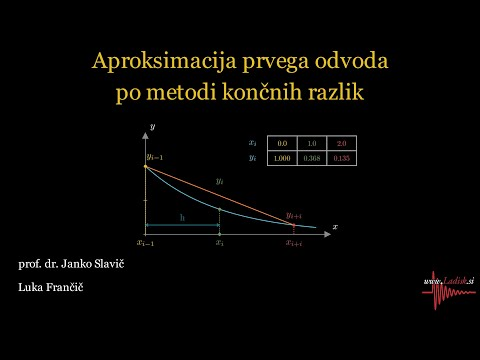

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('YYuGL-VP2BE', width=800, height=300)

The derivative $f'(x)$ can be approximated based on a Taylor series expansion. We call this method the **finite-difference method** or the **difference method**.

Let's expand the **forward Taylor series** (forward, because of the $+h$ term):

$$
f{\left (x + h \right )} =\sum_{n=0}^{\infty}\frac{h^n}{n!}\frac{d^n}{dx^n}f(x)= f{\left (x \right )} + h\, f'\left (x \right ) + \underbrace{\frac{h^2}{2}\,f''(x)+\cdots}_{\mathcal{O}\left(h^{2}\right)}
$$

The term $\mathcal{O}\left(h^{2}\right)$ denotes a second-order error. If we express the first derivative from the equation:

$$
f'{\left (x \right )}=\frac{1}{h}\left(f{\left (x + h \right )} - f{\left (x \right )}\right) - \underbrace{\frac{h}{2}\,f''(x)+\cdots}_{\mathcal{O}\left(h^{1}\right)}
$$

We find that we can estimate the first derivative at the point $x_i$ (that is: $f_o'(x_i)$) based on two consecutive function values:

$$
f_o'(x_i)=\frac{1}{h}\left(y_{i+1}-y_i\right)
$$

and in doing so we make a **method error**, which is of first order $\mathcal{O}\left(h^{1}\right)$.

We used $y_i=f(x_i)$ (see the figure above).

The error is:

$$e=-\frac{h}{2}\,f''(\xi),$$

where $\xi$ is an unknown value on the interval $[x_i, x_{i+1}]$ and we neglected the higher-order terms.

The following expression therefore holds:

$$f'(x_i)=f_o'(x_i)+e$$

Now let's see how we arrive at the same result with a machine-assisted derivation; first we import ``sympy``:

In [2]:
import sympy as sym
sym.init_printing()

Let's define the symbols:

In [3]:
f = sym.Function('f')
x, h = sym.symbols('x, h')

Then we continue with the **forward Taylor series** expansion:

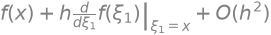

In [4]:
f(x+h).series(h, n=2)

The term $\mathcal{O}\left(h^{2}\right)$ contains terms of second and higher order. The equation above uses a temporary variable for differentiation $\xi_1$; let's carry out the differentiation and substitute $\xi_1=x$:

In [5]:
f(x+h).series(h, n=2).doit()

We write the equation:

In [6]:
equation = sym.Eq(f(x+h), f(x+h).series(h, n=2).doit())
equation

We solve it for the first derivative $f'(x)$:

In [7]:
f1_forward_exact = sym.solve(equation, f(x).diff(x))[0]
f1_forward_exact

If we do not account for the second- and higher-order derivatives, we have therefore made an error:

In [8]:
f1_forward_O = f1_forward_exact.expand().getO()
f1_forward_O

The error $\mathcal{O}\left(h^{1}\right)$ is therefore of first order, and if we neglect this term we make a *method error* and obtain an estimate of the derivative:

In [9]:
f1_forward_estimate = f1_forward_exact.expand().removeO()
f1_forward_estimate

We find that this is the same expression we derived above, so it is:

$$y_i'=\frac{1}{h}\left(-y_i+y_{i+1}\right).$$

The weights are therefore:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   | $y_{i}$   |$y_{i+1}$|
|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{h}\cdot$| -1 | 1 |

## Central difference scheme

### Derivative $f'(x)$

First let's look at the **backward Taylor series** expansion:

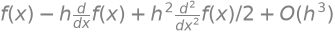

In [10]:
f(x-h).series(h, n=3).doit()

We find that in the difference between the forward and backward series the even-order terms cancel out; let's define:

In [11]:
def difference(n=3):
    return f(x+h).series(h, n=n).doit()-f(x-h).series(h, n=n).doit()
difference(n=3)

We carry out the following steps:

1. subtract the backward Taylor series from the forward series, the even-order derivatives cancel out,
2. solve the equation for the first derivative,
3. determine the method error,
4. determine the estimate of the derivative.

Let's carry out the steps above:

In [12]:
f1_cent_exact = sym.solve(
           sym.Eq(f(x+h) - f(x-h), difference(n=3)), # step 1
           f(x).diff(x))[0]                       # step 2
f1_cent_O = f1_cent_exact.expand().getO()         # step 3
f1_cent_estimate = f1_cent_exact.expand().removeO()  # step 4

The estimate of the 1st derivative is therefore:

In [13]:
f1_cent_estimate

Or:

$$y_i'=\frac{1}{2h}\left(-y_{i-1}+y_{i+1}\right)$$

The weights are therefore:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   |$y_{i-1}$ | $y_{i}$   |$y_{i+1}$|
|:--------:|:-------------------:|:----------:|:----------:|
|$y_i'=\frac{1}{2h}\cdot$| -1 | 0 | 1 |

The method error is therefore of second order:

In [14]:
f1_cent_O

### Example: $\exp(-x)$

Let's look at an example of the exponential function $f(x)=\exp(-x)$ and, for the point $x=1.0$, compute the first derivative $f'(x)=-\exp(-x)$ at the steps $h_0=1$ and $h_1=0.1$.

First we prepare a table of numerical values and the exact result:

In [15]:
import numpy as np
x0 = np.array([0., 1., 2.]) # step h=1
y0 = np.exp(-x0)
h0 = x0[1]-x0[0]

x1 = np.array([0.9, 1.0, 1.1]) # step h=0.1
y1 = np.exp(-x1)
h1 = x1[1]-x1[0]

f1_exact0 = - np.exp(-1) # exact result
f1_exact1 = - np.exp(-1) # exact result

Then we use the forward scheme:

In [16]:
f1_forward_estimate # as a reminder

In [17]:
f1_forward0 = (y0[1:]-y0[:-1])/h0   # step h_0
f1_forward1 = (y1[1:]-y1[:-1])/h1   # step h_1

Let's compute the error at $x=1.0$:

In [18]:
f1_exact0 - f1_forward0[1]

In [19]:
f1_exact1 - f1_forward1[1] # step h1

We can confirm that the error at step $h/10$ is indeed approximately 1/10 of that at step $h$.

Now let's also look at the error for the central difference scheme, which is of second order:

In [20]:
f1_cent_estimate

In [21]:
f1_cent0 = (y0[2:]-y0[:-2])/(2*h0) # step h_0
f1_cent1 = (y1[2:]-y1[:-2])/(2*h1) # step h_1

Let's analyze the error:

In [22]:
f1_exact0 - f1_cent0[0] # step h0

In [23]:
f1_exact1 - f1_cent1[0] # step h1

We can confirm that the error at step $h/10$ is indeed approximately 1/100 of that at step $h$.

### Derivative $f''(x)$

If we add the forward and backward Taylor series, the odd-order derivatives cancel out:

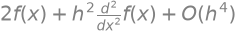

In [24]:
def total(n=3):
    return f(x+h).series(h, n=n).doit() + f(x-h).series(h, n=n).doit()
total(n=4)

Let's determine the second derivative:

In [25]:
f2_cent_exact = sym.solve(
           sym.Eq(f(x+h) + f(x-h), total(n=4)),   # step 1
           f(x).diff(x,2))[0]                     # step 2
f2_cent_O = f2_cent_exact.expand().getO()         # step 3
f2_cent_estimate = f2_cent_exact.expand().removeO()  # step 4

The estimate of the second derivative is:

In [26]:
f2_cent_estimate

Or:

$$y_i''=\frac{1}{h^2}\left(y_{i-1}-2\,y_{i}+y_{i+1}\right)$$

The weights are therefore:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   |$y_{i-1}$ | $y_{i}$   |$y_{i+1}$ |
|:--------:|:-------------------:|:----------:|:----------:|
|$y_i''=\frac{1}{h^2}\cdot$ | 1 | -2 | 1 |


The method error is again of second order:

In [27]:
f2_cent_O

### Derivative $f'''(x)$

If we want to determine the third derivative, we have to expand the Taylor series to order 5:

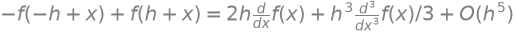

In [28]:
eq_h = sym.Eq(f(x+h)-f(x-h), difference(n=5))
eq_h

Using the 1st derivative we derived above would not help us, since the order of the error is $\mathcal{O}\left(h^{2}\right)$, which means that in the equation above, when dividing by $h^3$, we would get $\mathcal{O}\left(h^{-1}\right)$.

Let's use a trick: we repeat the expansion, but based on additional points that are $2h$ and $-2h$ away from $x$:

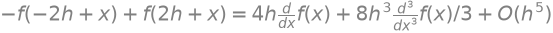

In [29]:
eq_2h = eq_h.subs(h, 2*h)
eq_2h

Now we have two equations and two unknowns; we will solve the system step by step:

1. solve equation `eq_h` for the first derivative,
2. solve equation `eq_2h` for the first derivative,
3. equate the results of the first two steps and solve for the third derivative,
4. determine the method error,
5. determine the estimate of the derivative.

Let's carry out the stated steps:

In [30]:
f3_cent_exact = sym.solve(
        sym.Eq(sym.solve(eq_h, f(x).diff(x))[0],  # step 1
        sym.solve(eq_2h, f(x).diff(x))[0]),       # step 2
        f(x).diff(x,3))[0]                        # step 3
f3_cent_O = f3_cent_exact.expand().getO()         # step 4
f3_cent_estimate = f3_cent_exact.expand().removeO()  # step 5

The estimate of the 3rd derivative is:

In [31]:
f3_cent_estimate

Or:

$$y_i'''=\frac{1}{h^3}\left(-y_{i-2}/2+y_{i-1}-y_{i+1}+y_{i+2}/2\right)$$

The weights are therefore:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   |$y_{i-2}$|$y_{i-1}$ | $y_{i}$   |$y_{i+1}$ |$y_{i+2}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'''=\frac{1}{h^3}\cdot$| -0.5 | 1 | 0 | -1 | 0.5|

Let's confirm that the method error is of second order:

In [32]:
f3_cent_O

### Derivative $f^{(4)}(x)$

Let's repeat a procedure similar to the one for the 3rd derivative, but for the 4th derivative we add the forward and backward Taylor series (up to order 6):

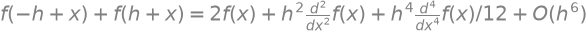

In [33]:
eq_h = sym.Eq(f(x+h)+f(x-h), total(n=6))
eq_h

Let's prepare an additional equation based on the points that are $2h$ and $-2h$ away from $x$:

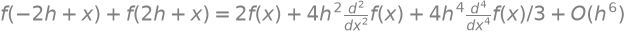

In [34]:
eq_2h = eq_h.subs(h, 2*h)
eq_2h

From the two equations we determine the 4th derivative:

In [35]:
f4_cent_exact = sym.solve(
        sym.Eq(sym.solve(eq_h, f(x).diff(x,2))[0],  # step 1
        sym.solve(eq_2h, f(x).diff(x,2))[0]),       # step 2
        f(x).diff(x,4))[0]                          # step 3
f4_cent_O = f4_cent_exact.expand().getO()           # step 4
f4_cent_estimate = f4_cent_exact.expand().removeO()    # step 5

The estimate of the 4th derivative is:

In [36]:
f4_cent_estimate

Or:

$$y_i^{(4)}=\frac{1}{h^4}\left(y_{i-2}-4\,y_{i-1}+6\,y_i-4\,y_{i+1}+y_{i+2}\right)$$

The weights are therefore:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   |$y_{i-2}$|$y_{i-1}$ | $y_{i}$   |$y_{i+1}$ |$y_{i+2}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| 1 | -4 | 6 | -4 | 1|

Let's confirm that the method error is of second order:

In [37]:
f4_cent_O

### Summary of the central difference scheme

Above we derived the first four derivatives with a 2nd-order method error. The key point of the derivations above is that they give us the **weights** by which we must multiply the function values in order to compute the approximation of a given derivative. For this reason, we will collect these weights here. If you are impatient, you can jump to the table below. Continue reading if you want to learn how to organize the previously derived expressions by machine.

First let's collect all the derivative estimates into a list:

In [38]:
derivatives = [f1_cent_estimate, f2_cent_estimate, f3_cent_estimate, f4_cent_estimate]
derivatives

We have 5 function values available (at locations $x-2h, x-h, x, x+h, x+2h$), which we put into a list:

In [39]:
function_values = [f(x-2*h), f(x-h), f(x), f(x+h), f(x+2*h)]

We compute the weight of the first derivative for the function value $f(x-h)$:

In [40]:
f1_cent_estimate.expand().coeff(function_values[1])

Now let's generalize and compute the weights for all function values and for all derivative estimates:

In [41]:
central_diff_scheme = [[derivative.expand().coeff(fv) for fv in function_values] \
                        for derivative in derivatives]
central_diff_scheme

The summaries above can also be written in tabular form:

|    Derivative $\downarrow$ $\backslash$ Values $\rightarrow$   |$y_{i-2}$|$y_{i-1}$ | $y_{i}$   |$y_{i+1}$ |$y_{i+2}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{h}\cdot$| 0     | -0.5 | 0 | 0.5 | 0|
|$y_i''=\frac{1}{h^2}\cdot$| 0 | 1 | -2 | 1 | 0|
|$y_i'''=\frac{1}{h^3}\cdot$| -0.5 | 1 | 0 | -1 | 0.5|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| 1 | -4 | 6 | -4 | 1|

The central difference scheme shown has a 2nd-order error $\mathcal{O}(h^{2})$.

Note: if you are interested in a generalization of the difference method, please see the [findiff](https://github.com/maroba/findiff) package.

### Improved approximation - Richardson extrapolation

If the exact derivative is computed as:

$$f'(x_i)=f_o'(x_i)+e,$$

where $f_o'(x_i)$ is the numerically computed derivative at the point $x_i$ and $e$ is the error estimate.

For a method of accuracy order $n$: $\mathcal{O}(h^{n})$ at step $h$ the following holds:

$$f'(x_i)=f_o'(x_i, h)+K\,h^n,$$

where $K$ is an unknown constant.

If we halve the step and assume that $K$ does not change, the following holds:

$$f'(x_i)=f_o'\left(x_i, \frac{h}{2}\right)+K\,\left(\frac{h}{2}\right)^n.$$

From both equations we eliminate the constant $K$ and determine the improved approximation:

$$\overline{f}'(x_i)=\frac{2^n\,f_o'\left(x_i, \frac{h}{2}\right)-f_o'(x_i, h)}{2^n-1}$$

#### Example

Let's look at the example $f(x)=\sin(x)$ (the analytical derivative is: $f'(x)=\cos(x)$):

In [42]:
x = np.linspace(0, 2*np.pi, 9)
y = np.sin(x)

At step $h$ we have the function values defined at:

In [43]:
x

array([0.        , 0.78539816, 1.57079633, 2.35619449, 3.14159265,
       3.92699082, 4.71238898, 5.49778714, 6.28318531])

The numerical derivative at $x=\pi$:

In [44]:
x[4]

and at step $h$ is

In [45]:
h = x[1] - x[0]
f_estimate_h = (-0.5*y[3] + 0.5*y[5])/h
f_estimate_h

The computation at step $2h$:

In [46]:
h2 = x[2] - x[0]
f_estimate_2h = (-0.5*y[2] + 0.5*y[6])/h2
f_estimate_2h

Let's compute the improved estimate for $x=\pi$:

In [47]:
f_estimate_improved = (2**2 * f_estimate_h - f_estimate_2h)/(2**2-1)
f_estimate_improved

We see that the improved estimate is closest to the theoretical value $\cos(\pi)=-1$.

## Non-central difference scheme

The central difference scheme we learned above is very useful and relatively accurate. However, since we cannot always use it (for example, at the beginning or end of the table), we have to rely on **non-central difference schemes** for computing derivatives.

We have:

* the **forward difference scheme**, which approximates the derivative at a point with the function values at the following points, and
* the **backward difference scheme**, which approximates the derivative at a point with the values at the preceding points.

The derivations are similar to what we showed for the central difference scheme, so we will not treat them here and will only show the final result.

### Forward difference scheme

Forward difference scheme with error order $\mathcal{O}(h^{1})$:

|  Derivative $\downarrow$ $\backslash$ Values $\rightarrow$        |$y_{i}$|$y_{i+1}$ | $y_{i+2}$   |$y_{i+3}$ |$y_{i+4}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{h}\cdot$| -1     | 1 | 0 | 0 | 0|
|$y_i''=\frac{1}{h^2}\cdot$| 1 | -2 | 1 | 0 | 0|
|$y_i'''=\frac{1}{h^3}\cdot$| -1 | 3 | -3| 1 | 0|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| 1 | -4 | 6 | -4 | 1|

Forward difference scheme with error order $\mathcal{O}(h^{2})$:

|  Derivative $\downarrow$ $\backslash$ Values $\rightarrow$        |$y_{i}$|$y_{i+1}$ | $y_{i+2}$   |$y_{i+3}$ |$y_{i+4}$|$y_{i+5}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{2h}\cdot$| -3 | 4 | -1| 0 | 0|  0|
|$y_i''=\frac{1}{h^2}\cdot$| 2 | -5 | 4 | -1| 0| 0|
|$y_i'''=\frac{1}{2h^3}\cdot$| -5 | 18| -24| 14| -3| 0|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| 3 | -14 | 26 | -24 | 11| -2|

### Backward difference scheme

Backward difference scheme with error order $\mathcal{O}(h^{1})$:

| Derivative $\downarrow$ $\backslash$ Values $\rightarrow$         |$y_{i-4}$|$y_{i-3}$ | $y_{i-2}$   |$y_{i-1}$ |$y_{i}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{h}\cdot$| 0 | 0| 0 | -1| 1|
|$y_i''=\frac{1}{h^2}\cdot$| 0 | 0 | 1 | -2| 1|
|$y_i'''=\frac{1}{h^3}\cdot$| 0 | -1| 3| -3| 1|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| 1 | -4 | 6 | -4 | 1|

Backward difference scheme with error order $\mathcal{O}(h^{2})$:

| Derivative $\downarrow$ $\backslash$ Values $\rightarrow$         |$y_{i-5}$|$y_{i-4}$|$y_{i-3}$ | $y_{i-2}$   |$y_{i-1}$ |$y_{i}$|
|:--------:|:-------------------:|:----------:|:----------:|:----------:|:----------:|:----------:|
|$y_i'=\frac{1}{2h}\cdot$| 0 | 0| 0| 1 |-4| 3|
|$y_i''=\frac{1}{h^2}\cdot$| 0 | 0 | -1| 4|-5| 2|
|$y_i'''=\frac{1}{2h^3}\cdot$| 0 | 3| -14| 24|-18| 5|
|$y_i^{(4)}=\frac{1}{h^4}\cdot$| -2| 11| -24| 26 | -14| 3|

## Using ``numpy.gradient``

To compute numerical derivatives (2nd-order central difference scheme) we can also use ``numpy.gradient()`` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html)):

```python
gradient(f, *varargs, **kwargs)
```

where `f` represents a table of values (in the form of a numerical array) of the function whose derivative we are looking for. `f` can be one or more dimensions. The positional parameters `varargs` define the spacing between the values of the argument of the function `f`; the default value is 1. This value can be a scalar, but it can also be a list of values of the independent variable (or even a combination of both). At the edges, the gradient method uses the forward or backward scheme; the parameter `edge_order` defines the order of the scheme used at the edges (we can choose between 1 or 2, the default value is 1).

The result of the `gradient` function is a numerical array (or an array of numerical arrays) with the computed derivatives.

For details see the [documentation](https://numpy.org/doc/stable/reference/generated/numpy.gradient.html).

For differentiating a function (and not a table of values), see: [`scipy.differentiate`](https://docs.scipy.org/doc/scipy/reference/differentiate.html).

### Example

We will look at an example of how to use the **weights**, the gradient function, and the special handling at the edges. First we prepare a table of data:

In [48]:
x, h = np.linspace(0, 1, 20, retstep=True)
y = np.sin(2*np.pi*x)

Weights of the difference schemes:

In [49]:
central = np.array([-0.5, 0, 0.5]) # weights of the central scheme; see also the findiff package (below)
forward = np.array([-3/2, 2, -1/2])
backward = np.array([1/2, -2, 3/2])

Now we compute the derivative of the interior points (the first way is with list comprehensions, the second is vectorized):

In [50]:
derivative_interior = np.array([y[i-1:i+2] @ central/h for i in range(1, len(x)-1)]) # list comprehension
derivative_interior = np.convolve(y, central[::-1], mode='valid') / h # vectorized

At the edges we use the forward or backward difference scheme:

In [51]:
derivative_first = y[:len(forward)] @ forward / h  # forward
derivative_last = y[-len(backward):] @ backward / h # backward

Let's assemble the result:

In [52]:
derivative_full = np.hstack([derivative_first, derivative_interior, derivative_last])

We display the result together with the result of the `np.gradient` function:

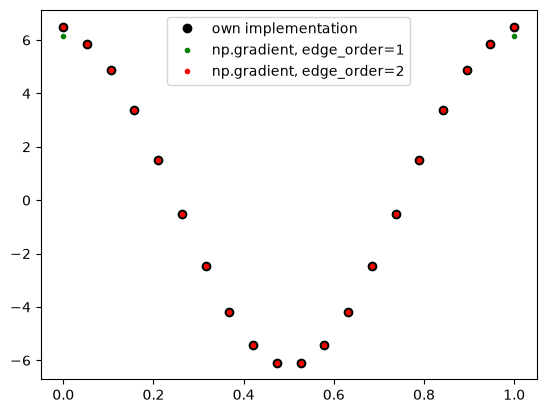

In [53]:
import matplotlib.pyplot as plt
%matplotlib inline
plt.plot(x, derivative_full, 'ko', lw=3, label='own implementation')
plt.plot(x, np.gradient(y, h), 'g.', label='np.gradient, edge_order=1')
plt.plot(x, np.gradient(y, h, edge_order=2), 'r.', label='np.gradient, edge_order=2')
plt.legend();

### Using `numpy.diff`

Let's also present here the frequently used function `numpy.diff` ([documentation](https://numpy.org/doc/stable/reference/generated/numpy.diff.html)), which computes the `n`-th discrete difference along a given axis. The first difference is given as $a[i+1] - a[i]$. This is the basic operation for numerical differentiation (it is a first-order accurate derivative), but we have to divide the result by the step $h$.

When using `np.diff`, the length of the array is reduced by 1.

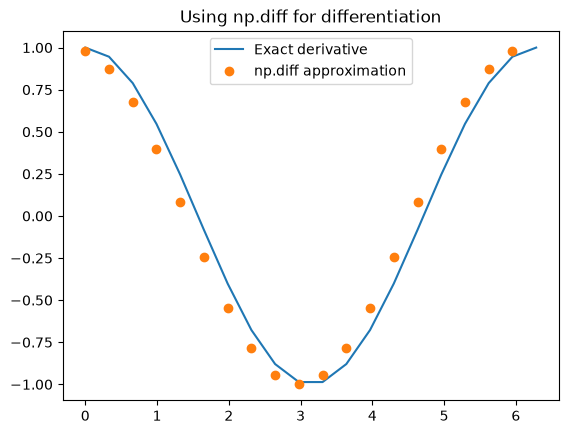

In [54]:
x_d = np.linspace(0, 2*np.pi, 20)
y_d = np.sin(x_d)
h_d = x_d[1] - x_d[0]

# First derivative with np.diff (forward difference)
dy = np.diff(y_d) / h_d
x_diff = x_d[:-1] # the x axis shrinks

plt.figure()
plt.plot(x_d, np.cos(x_d), label='Exact derivative')
plt.plot(x_diff, dy, 'o', label='np.diff approximation')
plt.legend()
plt.title('Using np.diff for differentiation')
plt.show()

## Round-off error in numerical differentiation

Above we focused on the method error. In numerical differentiation, however, we must also pay very close attention to the **round-off** (or *representation*) error! Let's look at the first derivative (using the central difference scheme) written with the method error ($k\,h^2$) and the round-off error $\varepsilon$:

$$y_i'=\frac{1}{2h}\left((-y_{i-1}\pm\varepsilon)+(y_{i+1}\pm\varepsilon)\right) + k\,h^2$$

In the worst case the round-off errors add up and the total error is:

$$n=\frac{\varepsilon}{h}+k\,h^2$$

When $h$ is large, the method error $k\,h^2$ dominates; when $h$ is small, the round-off error dominates. The error has a minimum when:

$$n'=-\frac{\varepsilon}{h^2}+2\,k\,h=0.$$

It follows that:

$$h=\sqrt[3]{\frac{\varepsilon}{2\,k}}.$$

### Example

Below we will look at an example where we vary the precision in three steps:

1. ``float16`` -
    16-bit format: sign 1 bit, exponent 5 bits, mantissa 10 bits
2. ``float32`` -
    32-bit format: sign 1 bit, exponent 8 bits, mantissa 23 bits
3. ``float64`` -
    64-bit format: sign 1 bit, exponent 11 bits, mantissa 52 bits (this is the default precision).

For more about types in ``numpy`` see the [documentation](https://numpy.org/doc/stable/user/basics.types.html)

Now let's determine the basic round-off error for each type:

In [55]:
eps16 = np.finfo(np.float16).eps
eps32 = np.finfo(np.float32).eps
eps64 = np.finfo(np.float64).eps
print(f'The basic round-off error for the types \
`float16`, `float32`, and `float64` is:\n{[eps16, eps32, eps64]}')

The basic round-off error for the types `float16`, `float32`, and `float64` is:
[np.float16(0.000977), np.float32(1.1920929e-07), np.float64(2.220446049250313e-16)]


As an example let's look at addition: we add half of the basic round-off error `eps16` to the number `1.` and convert to the type `float16`; we find that the new value is still equal to the value `1.`:

In [56]:
(1.+eps16/2).astype('float16')

np.float16(1.0)

First let's define the function $\exp(x)$, which will give a result with the precision defined by the parameter `dtype`:

In [57]:
def fun(x, dtype=float): # function
    return np.exp(-dtype(x)).astype(dtype)

Let's also define a function for the analytically determinable derivative (we will need this later to determine the relative error):

In [58]:
def f1_fun(x): # "exact" derivative of the function
    return -np.exp(-x)

Similarly to addition above, we can also see for the function value that a change in the value $x$ smaller than $\epsilon$ leads to the same result:

In [59]:
fun(1., dtype=np.float16)

np.float16(0.368)

In [60]:
fun(1+eps16/2, dtype=np.float16)

np.float16(0.368)

Now let's use the central difference scheme for the first derivative. Here the numbers should be written with precision `dtype`, and with the help of the exact derivative the relative error is also computed:

In [61]:
def f1_CDS(fun, x, h, dtype=np.float64):
    f1_estimate = (fun(x+h, dtype=dtype)-fun(x-h,dtype=dtype))/(2*dtype(h))
    f1_exact = f1_fun(x)
    relative_error = (f1_exact - f1_estimate) / f1_exact
    return f1_estimate, relative_error

Let's look at an example of the derivative at $x=1.0$ (the Python function returns the value and the relative error):

In [62]:
f1_CDS(fun, x=1., h=.01, dtype=np.float16)

(np.float16(-0.3662), np.float64(0.004535463210798897))

In [63]:
f1_CDS(fun, x=1., h=.01, dtype=np.float64)

Now let's define the step:

In [64]:
h=0.25**np.arange(30)
h[:10]

array([1.00000000e+00, 2.50000000e-01, 6.25000000e-02, 1.56250000e-02,
       3.90625000e-03, 9.76562500e-04, 2.44140625e-04, 6.10351562e-05,
       1.52587891e-05, 3.81469727e-06])

We compute the derivative estimate for various precisions (because of division by 0 we get a warning):

In [65]:
f1_16 = f1_CDS(fun, x=1., h=h, dtype=np.float16)
f1_32 = f1_CDS(fun, x=1., h=h, dtype=np.float32)
f1_64 = f1_CDS(fun, x=1., h=h, dtype=np.float64)

/tmp/ipykernel_355507/3908051182.py:2: RuntimeWarning: invalid value encountered in divide
  f1_estimate = (fun(x+h, dtype=dtype)-fun(x-h,dtype=dtype))/(2*dtype(h))


We plot the various types as a function of the step size $h$. First we import the required libraries:

In [66]:
import matplotlib.pyplot as plt
%matplotlib inline

Let's define the figure:

In [67]:
def fig_estimate():
    plt.semilogx(h, f1_16[0], 'b', lw=3, alpha=0.5, label='float16')
    plt.semilogx(h, f1_32[0], 'r', lw=3, alpha=0.5, label='float32')
    plt.semilogx(h, f1_64[0], 'g', lw=3, alpha=0.5, label='float64=float')
    plt.title('Derivative estimate for various precision types')
    plt.xlabel('$h$')
    plt.ylabel('Derivative estimate: $-\\exp(-1)=−0.3678794$')
    plt.ylim(-0.37, -0.365)
    plt.legend();

Let's display it:

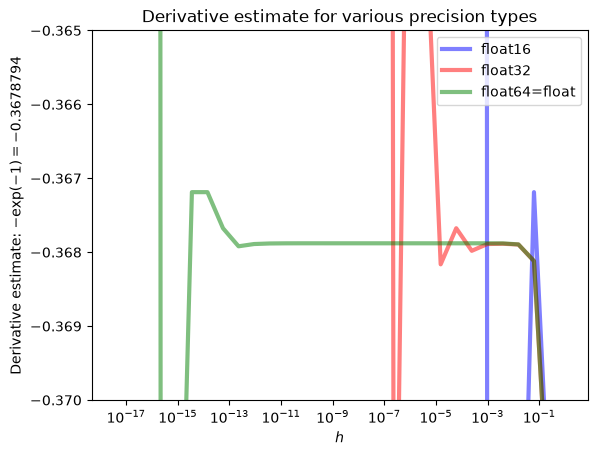

In [68]:
fig_estimate()

At a relatively large step $h$ the method error dominates, while at a small step the round-off error dominates; the optimal step can be estimated based on:

$$h=\sqrt[3]{\frac{\varepsilon}{2\,k}}.$$

In this particular case:

$$k=-\frac{f'''(x)}{6}=-\frac{-e^{-x}}{6}=\frac{1}{6\,e}\qquad(x=1)$$

It follows that:

$$h=\sqrt[3]{3\,\varepsilon\,e}.$$

We compute a suitable step for 16-, 32-, and 64-bit format:

In [69]:
np.power(3*eps16*np.exp(1),1/3)

In [70]:
np.power(3*eps32*np.exp(1),1/3)

In [71]:
np.power(3*eps64*np.exp(1),1/3)

The 64-bit format performs best, but even with it a step smaller than about `1e-5` is not recommended!

## Complex-step derivative approximation

The complex-step derivative approximation is useful when we have any analytic function defined but do not have an analytical expression for the first derivative; for details see ([source](https://nhigham.com/2020/10/06/what-is-the-complex-step-approximation/)). The idea stems from the Taylor series expansion of the function $f(x)$, but the step is taken in the direction of the imaginary axis $i\,h$ ($i=\sqrt(-1)$):

$$f{\left(x + i\,h \right)} = f{\left(x \right)} + i\,h\,\frac{d}{d x} f{\left(x \right)} - \frac{h^{2}}{2} \frac{d^{2}}{d x^{2}} f{\left(x \right)} + O\left(h^{3}\right)$$

If we now assume that the function $f(x)$ maps real values to the real axis and that $x$ and $h$ are real values, then we can derive:

$$\mathbf{Im} \left( f{\left(x + i\,h \right)}\right)= h\,\frac{d}{d x} f{\left(x \right)}+ O\left(h^{3}\right)$$

$$\mathbf{Re} \left( f{\left(x + i\,h \right)}\right) = f{\left(x \right)} - \frac{h^{2}}{2} \frac{d^{2}}{d x^{2}} f{\left(x \right)} + O\left(h^{3}\right)\rightarrow
\mathbf{Re} \left( f{\left(x + i\,h \right)}\right) = f{\left(x \right)} + O\left(h^{2}\right)$$

From the first equation (above) we then derive the expression for the first derivative:

$$f'{\left(x \right)}=\frac{\mathbf{Im} \left( f{\left(x + i\,h \right)}\right)}{h}+ O\left(h^{2}\right)$$

The result is in a way very surprising. Above, with a one-step forward scheme, we managed to obtain accuracy $O\left(h^{1}\right)$, while here it is $O\left(h^{2}\right)$!


An important advantage of the complex-step method is that it **has no problem with subtracting nearly equal numbers** (cancellation error), which plagues classical difference methods at very small steps $h$. Therefore we can choose an extremely small $h$ (e.g., $10^{-200}$) and obtain a practically exact result (down to machine precision).

If we now look at the use of the method on the example from above, $\exp(-x)$, let's first recall the exact result at the value $x=1$:

In [72]:
f1_exact0

When called with a step $h=0.1$ we get two (three) correct digits (similarly to the central difference scheme), and by reducing the step to one tenth we would roughly double the number of correct digits.

In [73]:
h1_complex = 0.1
y1_complex = np.exp(-(1.+1.j*h1_complex))
f1_complex = np.imag(y1_complex)/h1_complex
f1_complex

Since we have no problem with subtracting nearly equal numbers, we can reduce the step extremely and obtain an exact result (down to machine precision):

In [74]:
h1_complex = 1e-10
y1_complex = np.exp(-(1.+1.j*h1_complex))
f1_complex = np.imag(y1_complex)/h1_complex
f1_complex

In [75]:
np.sin(2*x0*1e-5j)

array([0.+0.e+00j, 0.+2.e-05j, 0.+4.e-05j])

In [76]:
np.sin(x0**2+2*x0*1e-5j)

array([ 0.        +0.00000000e+00j,  0.84147098+1.08060461e-05j,
       -0.7568025 -2.61457448e-05j])

Let's also look at an example of differentiating the function `sin(x**2)`. From the code and the figure below we can see a substantially faster convergence of the complex-step method. Why does the method work so well? If we substitute $x+i\,h$ into $x^2$, we get: $(x+i\,h)^2 = x^2 + 2i\,x\,h - h^2$

Since $h$ is very small, $h^2$ is negligible in the real part, while the imaginary part $2\,x\,h$ carries linearly through the sine. In this way we obtain an approximation of the theoretical derivative $2\,x\,\cos(x^2)$. The method *sees* the derivative in the imaginary part without subtraction, so no round-off error occurs.

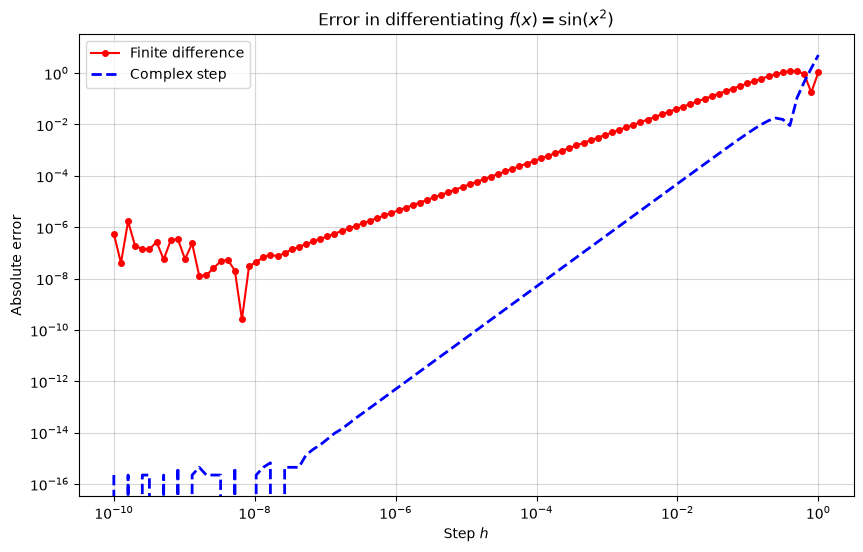

In [77]:
import matplotlib.pyplot as plt
import numpy as np

# Function: sin(x^2)
def f(x):
    return np.sin(x**2)

# Analytical derivative: 2x * cos(x^2)
def df_analytical(x):
    return 2*x * np.cos(x**2)

x0 = 1.5
exact = df_analytical(x0)

h_vals = np.logspace(-10, 0, 100)
err_fd = []
err_cs = []

for h in h_vals:
    # Finite difference (Forward)
    fd_approx = (f(x0 + h) - f(x0)) / h
    err_fd.append(abs(fd_approx - exact))

    # Complex step
    # f(x + ih) = sin((x+ih)^2) ≈ sin(x^2 + 2ixh)
    #           ≈ sin(x^2) + i * 2xh * cos(x^2)
    # Imag/h gives us exactly 2x*cos(x^2)
    cs_approx = f(x0 + 1j*h).imag / h
    err_cs.append(abs(cs_approx - exact))

plt.figure(figsize=(10, 6))
plt.loglog(h_vals, err_fd, 'r-o', label='Finite difference', markersize=4)
plt.loglog(h_vals, err_cs, 'b--', label='Complex step', linewidth=2)

plt.xlabel('Step $h$')
plt.ylabel('Absolute error')
plt.title(r'Error in differentiating $f(x)=\sin(x^2)$')
plt.grid(True, which="both", alpha=0.5)
plt.legend()
plt.show()

# Additional

[Lecture video on the topic of numerical differentiation](https://www.youtube.com/watch?v=ZJkGI5DZQv8&list=PLYdroRCLMg5OvLx1EtY1ByvveJeTEXQd_&index=18).

---

# Exercise questions

---

**Question 1:** The measured values of a runner's distance covered ``s`` are given at $N$ points in time. Numerically compute the velocity and acceleration profiles (you may use any method).

Observe and comment on what happens as you increase the number of points $N$.

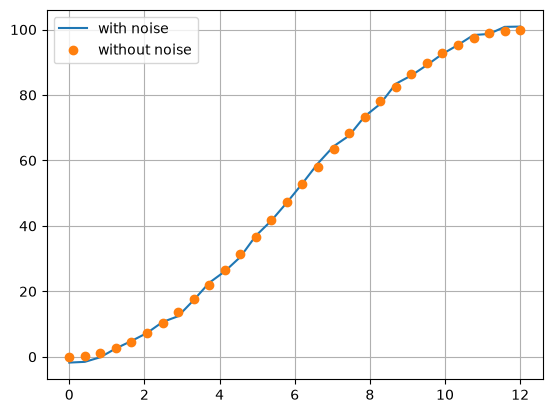

In [78]:
# Data
N = 30
t = np.linspace(0, 12, N)
s_ = 50*(np.cos(2*np.pi*(t-12)/24) +1)
s = s_ + np.random.randn(len(t))
plt.plot(t, s, '-', label='with noise')
plt.plot(t, s_, 'o', label='without noise')
plt.grid()
plt.legend()

**Question 2:** A function $f(x)$ and its derivative $f'(x)$ are given symbolically.

$$x(t) = e^{-t} \Big( \sin(\omega t) - 0.5 \cos(2 \omega t) \Big)$$

$$\omega = 2\pi f \quad \text{and} \quad f=4~\text{Hz}$$

We observe the function and its derivative at 100 time points $t\in [0, 1]$.

Prepare the functions `x_fun`, `dx_fun` for numerical computation. Plot the prepared functions on the interval $t\in [0, 1]$ using the `matplotlib` package.

In [80]:
# Data
import sympy as sym

t_sym = sym.Symbol('t', real=True, positive=True)
w = 2*sym.pi*4
x_sym = sym.exp(-t_sym) * (sym.sin(w*t_sym) - 0.5*sym.cos(2*w*t_sym))
dx_sym = sym.diff(x_sym, t_sym)

**Question 3:** Divide the observed time interval $t \in [0,1]$ into 100 equidistant segments.

Prepare a vector of values $x(t)$ and compute the derivative $x'(t)$ numerically as well, using the function ``numpy.gradient(x, h)``.

**Question 4:** Use the function ``np.gradient`` to also compute the second derivative $x''(t)$. Observe the effect of the `edge_order` parameter on the accuracy of the derivatives at the edges of the interval.

**Question 5:** To the numerical array $x(t)$ at 500 equidistant points on the interval $t \in [0, 1]$, add random noise $n(t)$ with amplitude $A=0.1$ using the function ``np.random.randn``.

$$x_{\text{noise}}(t) = x(t) + A\cdot n(t)$$

Using the function ``np.gradient``, numerically determine the value of the first and second derivative of the noisy signal.

------

### Weights of difference schemes with the ``findiff`` package


**Example 6:** Compute the values of the second derivative $x''(t)$. Use the central difference scheme for the second derivative over 5 points (error order 4).

In [85]:
# Data
#!pip install findiff
import findiff
findiff.coefficients(deriv=2, acc=4)['center']['coefficients']

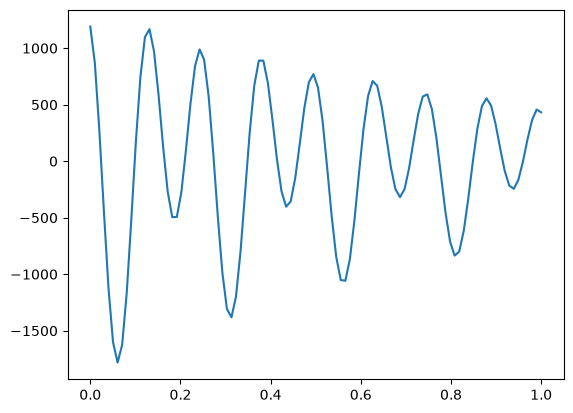

In [86]:
t, dt = np.linspace(0, 1, 100, retstep=True)
x = sym.lambdify(t_sym, x_sym)(t)
second_derivative = findiff.Diff(0, dt, acc=4)**2 # axis, step, accuracy; **2 means the second derivative
plt.plot(t, second_derivative(x))

**Question 7:** Based on the numerical data $x(t)$, with the interval $t \in [0,1]$ divided into 100 points, compute the value of the first derivative $x'(t)$ using the central difference scheme equation over three points. Can you determine the value of the derivative at the points $t=0$ and $t=1$ this way?

In [87]:
# Data
w = np.array([-1/2, 0, 1/2])

**Question 8:** Using the forward or backward difference scheme, compute the first derivative $x'(t)$ at the edge points as well ($t=0$, $t=1$). Compare the obtained values with the result of the function ``np.gradient``, where you set the argument ``edge_order=2``.

$$
\begin{align}
\text{forward: } & \frac{d}{dx}f(x) = \frac{1}{2h}\Big( -3f(x) + 4f(x+h) -f(x+2h)\Big)\\
\text{backward: } & \frac{d}{dx}f(x) = \frac{1}{2h}\Big(f(x-2h) - 4f(x-h) + 3f(x)\Big)
\end{align}$$

(Hint: you may use the function ``np.dot``)

In [89]:
# Data
forward = np.array([-3/2, 2, -1/2])
backward = np.array([1/2, -2, 3/2])

--------

### Improving the derivative approximation with Richardson extrapolation

**Question 9:** Compute the improved approximation of the derivative of the function:

$$x(t) = e^{-t} \Big( \sin(8 \pi t) - 0.5 \cos(16 \pi t) \Big)$$

at the value $t_i = 0.5$, by using the equation above for two different subdivisions, $h=0.05$ and $h/2 = 0.025$. Use the central difference scheme for the 1st derivative with error order $n=2$.

--------

### Using ``np.convolve``

<img src="fig/vaje/primer_convolve.gif">

**Question 10:** Use the function ``np.convolve`` and compute the values of the second derivative $x(t)$ with the interval $t \in [0, 1]$ divided into 100 points. Use the central difference scheme for the second derivative over 5 points, computing the weights with the help of the ``findiff`` package (function ``findiff.coefficients``).

Display the result graphically (mind the number of edge points!).